In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import joblib
import pandas as pd
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [15]:
X = joblib.load('diff_images_after_compress.joblib')
actual_images = joblib.load('actual_images_after_compress.joblib')
expected_images = joblib.load('expected_images_after_compress.joblib') 
y = joblib.load('y_labels.joblib')

X = np.array(X, dtype=object)  
actual_images = np.array(actual_images, dtype=object)
expected_images = np.array(expected_images, dtype=object)
y = np.array(y)

subtype_labels = []
for i in range(len(X)):
    if i < 100:
        subtype_labels.append('disappeared')
    elif i < 150:
        subtype_labels.append('color_change')
    elif i < 200:
        subtype_labels.append('shift')
    elif i < 300:
        subtype_labels.append('dynamic')
    else:
        subtype_labels.append('banner')

subtype_labels = np.array(subtype_labels)

Train: 222, Val: 56, Test: 120
Using device: cpu

Epoch 1/30


Validation: 100%|█████████████████████████████████| 4/4 [00:02<00:00,  1.87it/s]


Train Loss: 0.7101, Train Acc: 53.60%
Val Loss: 0.5496, Val Acc: 80.36%
Model saved with Val Acc: 80.36%

Epoch 2/30


Validation: 100%|█████████████████████████████████| 4/4 [00:02<00:00,  1.81it/s]


Train Loss: 0.6002, Train Acc: 63.06%
Val Loss: 0.4924, Val Acc: 78.57%

Epoch 3/30


...

Train Loss: 0.2336, Train Acc: 90.09%
Val Loss: 0.1808, Val Acc: 92.86%

Epoch 30/30


Validation: 100%|█████████████████████████████████| 4/4 [00:02<00:00,  1.84it/s]


Train Loss: 0.2418, Train Acc: 90.99%
Val Loss: 0.1903, Val Acc: 92.86%


Validation: 100%|█████████████████████████████████| 8/8 [00:04<00:00,  1.69it/s]



Test Loss: 0.2251, Test Acc: 92.50%

Classification Report:
              precision    recall  f1-score   support

     Not Bug       0.90      0.95      0.93        60
         Bug       0.95      0.90      0.92        60

    accuracy                           0.93       120
   macro avg       0.93      0.93      0.92       120
weighted avg       0.93      0.93      0.92       120



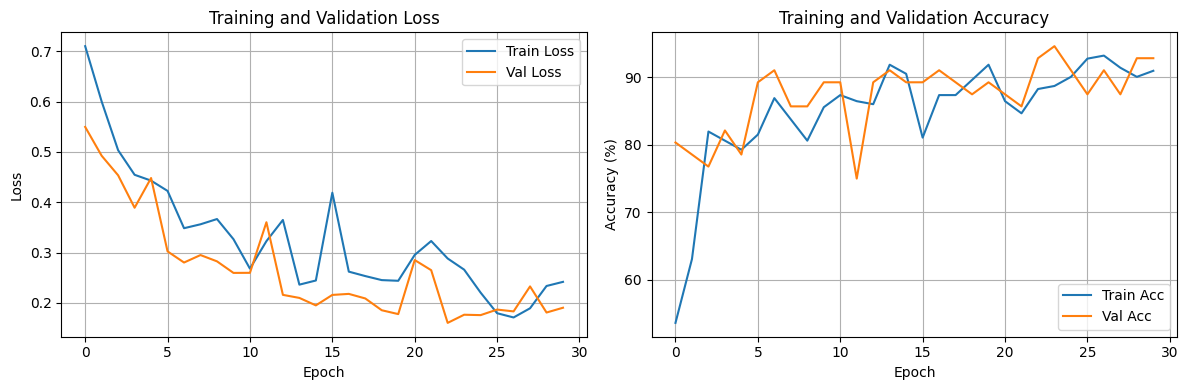

In [36]:
class ThreeChannelDiffDataset(Dataset):
    def __init__(self, expected_images, actual_images, diff_images, labels, transform=None):
        self.expected_images = expected_images
        self.actual_images = actual_images
        self.diff_images = diff_images
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        expected = self.expected_images[idx]
        actual = self.actual_images[idx]
        diff = self.diff_images[idx]
        
        # Приводим все к 2D
        def to_2d(img):
            if len(img.shape) == 3:
                if img.shape[-1] == 3:
                    return np.mean(img, axis=-1)
                else:
                    return img[:, :, 0]
            return img
        
        expected = to_2d(expected)
        actual = to_2d(actual)
        diff = to_2d(diff)
        
        # Комбинируем три изображения в трехканальное
        # Каждое изображение становится отдельным каналом
        combined = np.stack([expected, actual, diff], axis=-1)
        
        if combined.dtype != np.uint8:
            if combined.max() <= 1.0:
                combined = (combined * 255).astype(np.uint8)
            else:
                combined = combined.astype(np.uint8)
        
        # Создаем RGB изображение
        img = Image.fromarray(combined, mode='RGB')
        
        if self.transform:
            img = self.transform(img)
        
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label
        

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])


class DiffClassifier(nn.Module):
    def __init__(self, num_classes=2, freeze_backbone=True):
        super(DiffClassifier, self).__init__()
        
        # Загружаем предобученную MobileNetV2
        self.backbone = models.mobilenet_v2(pretrained=True)
        
        # Замораживаем backbone (опционально)
        if freeze_backbone:
            for param in self.backbone.features.parameters():
                param.requires_grad = False
        
        # Заменяем классификатор
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)


def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(dataloader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels


def train_model(X, y, subtype_labels, expected_images, actual_images,
                num_epochs=30, 
                batch_size=16, 
                learning_rate=0.001,
                freeze_backbone=True):
    
    original_indixes = np.arange(len(X))
    
    X_train, X_test, y_train, y_test, sub_train, sub_test, idx_train, idx_test = train_test_split(
        X, y, subtype_labels, original_indixes,
        test_size=0.3,
        stratify=subtype_labels,
        random_state=69
    )
    
    exp_train, exp_test = expected_images[idx_train], expected_images[idx_test]
    act_train, act_test = actual_images[idx_train], actual_images[idx_test]
    
    X_train, X_val, y_train, y_val, exp_train, exp_val, act_train, act_val = train_test_split(
        X_train, y_train, exp_train, act_train,
        test_size=0.2, 
        stratify=y_train, 
        random_state=69
    )
    
    print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
    
    train_dataset = ThreeChannelDiffDataset(
        expected_images=exp_train,
        actual_images=act_train,
        diff_images=X_train,
        labels=y_train,
        transform=train_transform
    )
    
    val_dataset = ThreeChannelDiffDataset(
        expected_images=exp_val,
        actual_images=act_val,
        diff_images=X_val,
        labels=y_val,
        transform=val_transform
    )
    
    test_dataset = ThreeChannelDiffDataset(
        expected_images=exp_test,
        actual_images=act_test,
        diff_images=X_test,
        labels=y_test,
        transform=val_transform
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    model = DiffClassifier(num_classes=2, freeze_backbone=freeze_backbone)
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        val_loss, val_acc, _, _ = validate_epoch(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        scheduler.step(val_loss)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"Model saved with Val Acc: {val_acc:.2f}%")
    
    model.load_state_dict(torch.load('best_model.pth'))
    
    test_loss, test_acc, test_preds, test_labels = validate_epoch(
        model, test_loader, criterion, device
    )
    
    print(f"\n{'='*60}")
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    print(f"\nClassification Report:")
    print(classification_report(test_labels, test_preds, target_names=['Not Bug', 'Bug']))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(train_accs, label='Train Acc')
    ax2.plot(val_accs, label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=100)
    plt.show()
    
    return model, test_preds, test_labels, idx_test, test_loader, device
    

model, test_preds, test_labels, idx_test, test_loader, device = train_model(
    X=X,
    y=y,
    subtype_labels=subtype_labels,
    expected_images=expected_images,
    actual_images=actual_images,
    num_epochs=30,
    batch_size=16,
    learning_rate=0.001,
    freeze_backbone=True
)

In [37]:
test_preds_array = np.array(test_preds)
test_labels_array = np.array(test_labels)

error_indexes = np.where(test_preds_array != test_labels_array)[0]

print(f"Number of errors: {len(error_indexes)}")
print(f"Error indices in test set: {error_indexes}")

false_positives = np.where((test_preds_array == 1) & (test_labels_array == 0))[0]
false_negatives = np.where((test_preds_array == 0) & (test_labels_array == 1))[0]

print(f"False Positives (FP): {len(false_positives)}, indices: {false_positives}")
print(f"False Negatives (FN): {len(false_negatives)}, indices: {false_negatives}")

Number of errors: 9
Error indices in test set: [ 24  30  33  36  49  94 110 113 119]
False Positives (FP): 3, indices: [ 24  33 110]
False Negatives (FN): 6, indices: [ 30  36  49  94 113 119]


Индексы с ошибками [303 192 339 191  49 184 356   1  26]


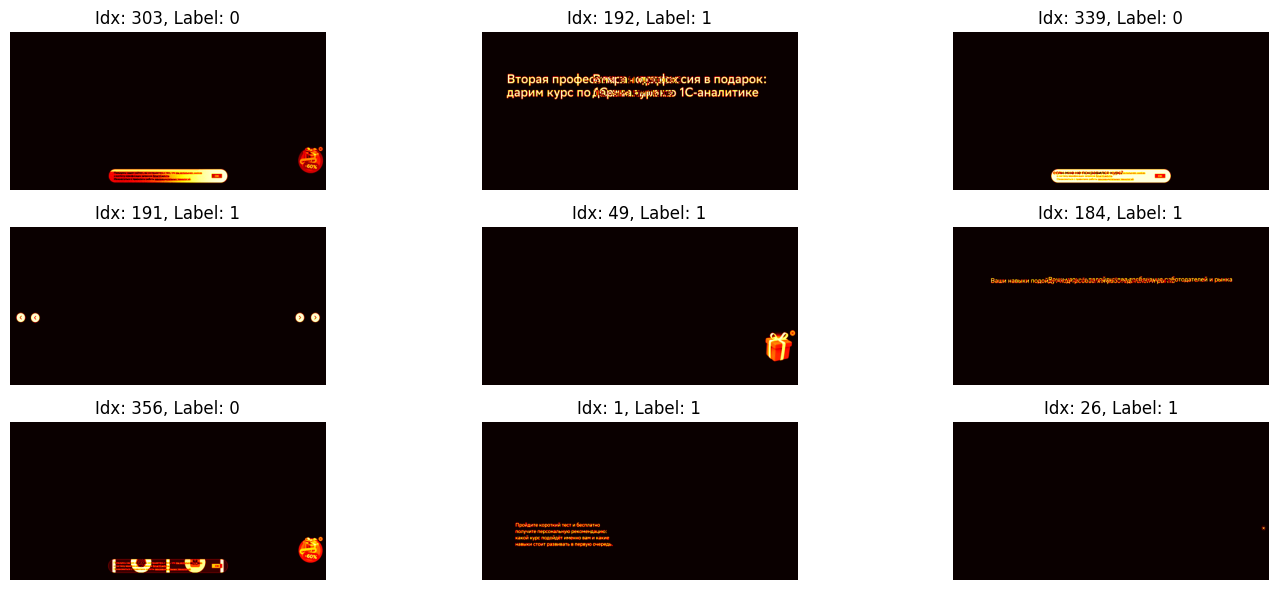

In [44]:
incorrect_original_indixes = idx_test[error_indexes]
print(f"Индексы с ошибками {incorrect_original_indixes}")
X = joblib.load('diff_images_after_compress.joblib')


fig, axes = plt.subplots(3, 3, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(incorrect_original_indixes):
        idx = incorrect_original_indixes[i]
        if idx < len(X):
            ax.imshow(X[idx], cmap='hot')
            ax.set_title(f'Idx: {idx}, Label: {y[idx]}')
            ax.axis('off')
plt.tight_layout()
plt.show()

In [49]:
def analyze_predictions_by_subtype(model, test_loader, device, idx_test, subtype_labels, y_test):
    """
    Анализирует ошибки модели по типам (подтипам) изображений
    """
    model.eval()
    
    all_preds = []
    all_labels = []
    all_indices = []
    
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(test_loader):
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            
            # Получаем индексы для этого батча
            start_idx = batch_idx * test_loader.batch_size
            end_idx = min(start_idx + test_loader.batch_size, len(idx_test))
            batch_indices = idx_test[start_idx:end_idx]
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_indices.extend(batch_indices)
    
    results_df = pd.DataFrame({
        'idx': all_indices,
        'true_label': all_labels,
        'pred_label': all_preds,
        'subtype': [subtype_labels[idx] for idx in all_indices]
    })
    
    results_df['is_error'] = results_df['true_label'] != results_df['pred_label']
    
    print("="*80)
    print("АНАЛИЗ ОШИБОК ПО ТИПАМ ИЗОБРАЖЕНИЙ")
    print("="*80)
    
    subtype_stats = results_df.groupby('subtype').agg({
        'idx': 'count',
        'is_error': ['sum', 'mean'],
        'true_label': lambda x: (x == 1).sum()  # количество багов
    }).round(3)
    
    subtype_stats.columns = ['total_samples', 'errors_count', 'error_rate', 'bug_count']
    subtype_stats['accuracy'] = 1 - subtype_stats['error_rate']
    
    print("\nСТАТИСТИКА ПО ТИПАМ:")
    print(subtype_stats)
    
    print("\n" + "="*80)
    print("MATRIX ОШИБОК ДЛЯ КАЖДОГО ТИПА:")
    print("="*80)
    
    subtype_confusion = {}
    for subtype in results_df['subtype'].unique():
        subtype_data = results_df[results_df['subtype'] == subtype]
        
        unique_true = subtype_data['true_label'].unique()
        unique_pred = subtype_data['pred_label'].unique()
        all_classes = sorted(set(unique_true) | set(unique_pred))
        
        if len(all_classes) == 1:
            print(f"\n{subtype}:")
            print(f"  Only class {all_classes[0]} present in this subtype")
            print(f"  All predictions are correct? {len(subtype_data[subtype_data['is_error']]) == 0}")
            
            only_class = all_classes[0]
            if only_class == 0:
                cm = np.array([[len(subtype_data), 0], 
                               [0, 0]])
            else:
                cm = np.array([[0, 0], 
                               [0, len(subtype_data)]])
            subtype_confusion[subtype] = cm
            
            print(f"Confusion Matrix:")
            print(cm)
            print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
            print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")
            
            tn, fp, fn, tp = cm.ravel()
            accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            print(f"Accuracy: {accuracy:.3f}")
            print(f"Precision: {precision:.3f} (only one class present)")
            print(f"Recall: {recall:.3f} (only one class present)")
            print(f"F1-Score: {f1:.3f} (only one class present)")
            
        else:
            cm = confusion_matrix(subtype_data['true_label'], subtype_data['pred_label'], 
                                 labels=[0, 1])
            subtype_confusion[subtype] = cm
            
            print(f"\n{subtype}:")
            print(f"Confusion Matrix:")
            print(cm)
            print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
            print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")
            
            tn, fp, fn, tp = cm.ravel()
            accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            print(f"Accuracy: {accuracy:.3f}")
            print(f"Precision: {precision:.3f}")
            print(f"Recall: {recall:.3f}")
            print(f"F1-Score: {f1:.3f}")
    
    return results_df, subtype_stats, subtype_confusion

def plot_subtype_analysis(results_df, subtype_stats):
    """
    Визуализация ошибок по подтипам
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    ax1 = axes[0, 0]
    subtype_stats_sorted = subtype_stats.sort_values('error_rate', ascending=False)
    colors = ['red' if x > 0.3 else 'orange' if x > 0.15 else 'green' 
              for x in subtype_stats_sorted['error_rate']]
    ax1.bar(subtype_stats_sorted.index, subtype_stats_sorted['error_rate'] * 100, 
            color=colors, alpha=0.7)
    ax1.set_title('Error Rate by Subtype', fontsize=14)
    ax1.set_xlabel('Subtype')
    ax1.set_ylabel('Error Rate (%)')
    ax1.axhline(y=15, color='orange', linestyle='--', label='Warning threshold (15%)')
    ax1.axhline(y=30, color='red', linestyle='--', label='Critical threshold (30%)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[0, 1]
    ax2.bar(subtype_stats.index, subtype_stats['total_samples'], alpha=0.7, color='skyblue')
    ax2.set_title('Number of Samples by Subtype', fontsize=14)
    ax2.set_xlabel('Subtype')
    ax2.set_ylabel('Count')
    ax2.grid(True, alpha=0.3)
    
    ax3 = axes[0, 2]
    ax3.bar(subtype_stats.index, subtype_stats['accuracy'] * 100, alpha=0.7, color='lightgreen')
    ax3.set_title('Accuracy by Subtype', fontsize=14)
    ax3.set_xlabel('Subtype')
    ax3.set_ylabel('Accuracy (%)')
    ax3.axhline(y=85, color='green', linestyle='--', label='Good (85%)')
    ax3.set_ylim([0, 100])
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    ax4 = axes[1, 0]
    error_counts = results_df.groupby(['subtype', 'is_error']).size().unstack(fill_value=0)
    if 'False' not in error_counts.columns:
        error_counts['False'] = 0
    if 'True' not in error_counts.columns:
        error_counts['True'] = 0
    error_counts = error_counts[['False', 'True']]
    error_counts.columns = ['Correct', 'Wrong']
    error_counts.plot(kind='bar', stacked=True, ax=ax4, color=['green', 'red'], alpha=0.7)
    ax4.set_title('Correct vs Wrong Predictions by Subtype', fontsize=14)
    ax4.set_xlabel('Subtype')
    ax4.set_ylabel('Count')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    ax5 = axes[1, 1]
    error_dist = results_df[results_df['is_error']]['subtype'].value_counts()
    if len(error_dist) > 0:
        ax5.pie(error_dist.values, labels=error_dist.index, autopct='%1.1f%%', 
                startangle=90, colors=plt.cm.Set3(range(len(error_dist))))
        ax5.set_title('Error Distribution by Subtype', fontsize=14)
    else:
        ax5.text(0.5, 0.5, 'No errors!', 
                transform=ax5.transAxes, fontsize=14, ha='center', va='center')
        ax5.set_title('Error Distribution by Subtype', fontsize=14)
    
    ax6 = axes[1, 2]
    ax6.text(0.1, 0.5, 
             f"Total samples: {len(results_df)}\n"
             f"Total errors: {results_df['is_error'].sum()}\n"
             f"Overall error rate: {results_df['is_error'].mean():.2%}\n"
             f"Best subtype: {subtype_stats['accuracy'].idxmax()} ({subtype_stats['accuracy'].max():.2%})\n"
             f"Worst subtype: {subtype_stats['accuracy'].idxmin()} ({subtype_stats['accuracy'].min():.2%})",
             transform=ax6.transAxes, fontsize=12, verticalalignment='center')
    ax6.set_title('Summary Statistics', fontsize=14)
    ax6.axis('off')
    
    plt.tight_layout()
    plt.savefig('subtype_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

In [50]:
results_df, subtype_stats, subtype_confusion = analyze_predictions_by_subtype(
    model=model,
    test_loader=test_loader,
    device=device,
    idx_test=idx_test,
    subtype_labels=subtype_labels,
    y_test=y
)

АНАЛИЗ ОШИБОК ПО ТИПАМ ИЗОБРАЖЕНИЙ

СТАТИСТИКА ПО ТИПАМ:
              total_samples  errors_count  error_rate  bug_count  accuracy
subtype                                                                   
banner                   30             3         0.1          0       0.9
color_change             15             0         0.0         15       1.0
disappeared              30             3         0.1         30       0.9
dynamic                  30             0         0.0          0       1.0
shift                    15             3         0.2         15       0.8

MATRIX ОШИБОК ДЛЯ КАЖДОГО ТИПА:

banner:
Confusion Matrix:
[[27  3]
 [ 0  0]]
True Negatives: 27, False Positives: 3
False Negatives: 0, True Positives: 0
Accuracy: 0.900
Precision: 0.000
Recall: 0.000
F1-Score: 0.000

disappeared:
Confusion Matrix:
[[ 0  0]
 [ 3 27]]
True Negatives: 0, False Positives: 0
False Negatives: 3, True Positives: 27
Accuracy: 0.900
Precision: 1.000
Recall: 0.900
F1-Score: 0.947

color_c

## Выводы:

Предобученная нейронная сеть дала с хода Test Acc: 92.50%!
Это чуть хуже чем классическая модель, но факт - у нас слишком мало тестовых данных для обучения!
Тем более, что пришлось делить на train, validation и test. Получилось, что для некоторых типов это всего 15 скриншотов.
Но время и ресурсы затрачиваемые на нейронную сеть намного больше. В реальных условиях эксплуатации при намного большем количестве скриншотов нужно будет ещё раз сравнить их показатели.
Смысла писать собственную нейронную сеть или пробовать другие, когда тестовых данных недостаточно бессмысленно.
Примечательно, что ошибки были на других скриншотах и половина это были баннеры, которые можно исключить на самом деле.